In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
# loading dataset
df = sns.load_dataset("tips")

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [7]:
# basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [8]:
# Measure of Central Tendecy
print("Columns: ", df.columns)

Columns:  Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [9]:
col = df["total_bill"]

In [18]:
mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()
print("Total_Bill:")
print("mean:",mean_val)
print("median:",median_val)
print("mode:",mode_val[0])

Total_Bill:
mean: 19.78594262295082
median: 17.795
mode: 13.42


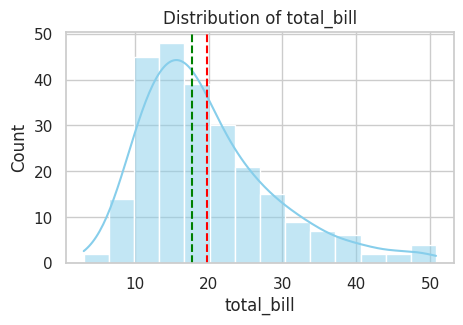

In [29]:
# Distribution Curve

col = df["total_bill"]

mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()
plt.figure(figsize= (5,3))
sns.histplot(col,kde = True, color="skyblue")
plt.axvline(mean_val, color = "red", linestyle ="--", label = "Mean Value")
plt.axvline(median_val, color = "green", linestyle ="--", label = "Median Value")

plt.title("Distribution of total_bill")
plt.show()


In [35]:
# Measure of spread

# range
data_range = col.max() - col.min()

# variance
variance = np.var(col)

#std
std_dev = np.std(col)

#Inter quartile range
Q1 = np.percentile(col, 25)
Q3 = np.percentile(col, 75)
iqr = Q3 - Q1

print("Range:",data_range)
print("variance:",variance)
print("Standar Deviation:",std_dev)
print("IQR:", iqr)

Range: 47.74
variance: 78.92813148851113
Standar Deviation: 8.88415057777113
IQR: 10.779999999999998


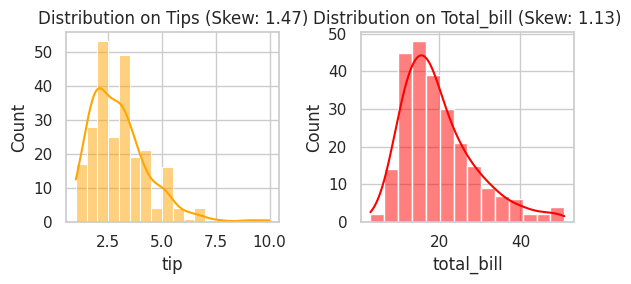

In [41]:
# Data Distribution Skewness
plt.figure(figsize = (6,3))

#plot 1: Tip Distribution
plt.subplot(1,2,1)
sns.histplot(df["tip"], kde=True, color = "orange")
plt.title(f"Distribution on Tips (Skew: {df["tip"].skew():.2f})")

#plot 2: Total_bill Distribution
plt.subplot(1,2,2)
sns.histplot(df["total_bill"], kde=True, color = "red")
plt.title(f"Distribution on Total_bill (Skew: {df["total_bill"].skew():.2f})")

plt.tight_layout()
plt.show()

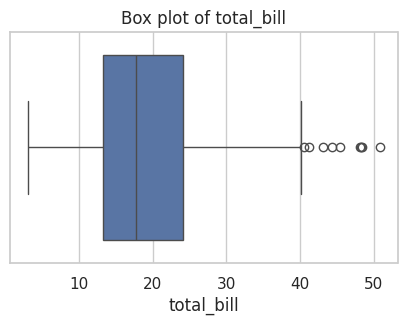

lower bound: -2.8224999999999945
upper bound: 40.29749999999999
Number of outliers: 9


In [48]:
# Outlier detection

# 1. Visual method
plt.figure(figsize = (5,3))
sns.boxplot(x=df["total_bill"])
plt.title("Box plot of total_bill")
plt.show()

# formula method
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("lower bound:",lower_bound)
print("upper bound:",upper_bound)

# filter outliers
outliers = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]
print("Number of outliers:", len(outliers))

Correaltion Matrix:
             total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


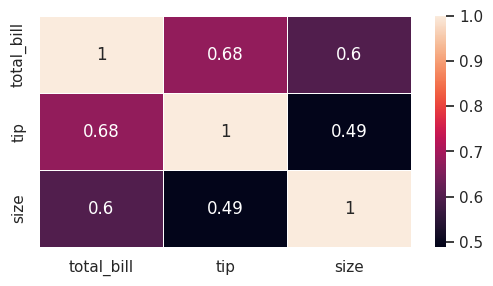

In [57]:
# Correlation Analysis
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
print("Correaltion Matrix:\n",corr_matrix)

plt.figure(figsize = (6,3))
sns.heatmap(corr_matrix, annot = True, linewidths=0.5)
plt.show()
